# QSAR Pipeline Debug & Execution Notebook

This notebook runs the complete QSAR machine learning pipeline with detailed diagnostics to ensure all outputs are generated correctly.

**Goal**: Generate all expected output files in the `outputs/` folder:
- `ic50_distribution.png` - IC50 value distribution
- `umap_clusters.png` - Chemical space clustering visualization
- `y_true_vs_pred.png` - Model performance scatter plot
- `SeriesE_with_predictions.csv` - Predictions for Series E compounds
- `SeriesC_test_with_predictions.csv` - Test set predictions
- `model_results.csv` - Results from all 84 model combinations

In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
np.random.seed(42)

warnings.filterwarnings("ignore")

# Set working directory
work_dir = "/Users/nb/Documents/Tzu-qsar-generative-model"
os.chdir(work_dir)
sys.path.insert(0, work_dir)

print("=" * 80)
print("QSAR PIPELINE DEBUG & EXECUTION")
print("=" * 80)
print(f"\n✓ Working Directory: {os.getcwd()}")
print(f"✓ Python Path: {sys.path[0]}")

# Verify output directory exists
output_dir = os.path.join(work_dir, "outputs")
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Output Directory: {output_dir}")

# List existing files
print(f"\nExisting files in outputs/:")
for fname in os.listdir(output_dir):
    fpath = os.path.join(output_dir, fname)
    size = os.path.getsize(fpath)
    print(f"  - {fname} ({size} bytes)")

QSAR PIPELINE DEBUG & EXECUTION

✓ Working Directory: /Users/nb/Documents/Tzu-qsar-generative-model
✓ Python Path: /Users/nb/Documents/Tzu-qsar-generative-model
✓ Output Directory: /Users/nb/Documents/Tzu-qsar-generative-model/outputs

Existing files in outputs/:
  - ic50_distribution.png (2398 bytes)


In [2]:
print("\n" + "=" * 80)
print("IMPORTING MODULES")
print("=" * 80)

try:
    from data_loader import (load_excel_sheets, apply_smiles_cleaning,
                             combine_and_deduplicate, filter_numeric_ic50,
                             standardize_smiles)
    print("✓ data_loader imported")
except Exception as e:
    print(f"✗ data_loader ERROR: {e}")
    raise

try:
    from descriptors import compute_descriptors
    print("✓ descriptors imported")
except Exception as e:
    print(f"✗ descriptors ERROR: {e}")
    raise

try:
    from clustering import run_umap, run_hdbscan, get_scaffold_safe, analyze_chemical_space
    print("✓ clustering imported")
except Exception as e:
    print(f"✗ clustering ERROR: {e}")
    raise

try:
    from model import train_and_select, predict_and_antilog
    print("✓ model imported")
except Exception as e:
    print(f"✗ model ERROR: {e}")
    raise

try:
    from visualization import (plot_ic50_distribution, plot_ic50_boxplot,
                               univariate_analysis, plot_umap_clusters,
                               plot_y_true_vs_pred)
    print("✓ visualization imported")
except Exception as e:
    print(f"✗ visualization ERROR: {e}")
    raise

print("\n✅ All modules loaded successfully!")

import matplotlib.pyplot as plt
from rdkit import Chem
print("✓ matplotlib and rdkit verified")


IMPORTING MODULES
✓ data_loader imported
✓ descriptors imported
✓ clustering imported
✓ model imported
✓ visualization imported

✅ All modules loaded successfully!
✓ matplotlib and rdkit verified


In [17]:
print("\n" + "="*80)
print("[STEP 1/6] LOADING AND PREPROCESSING DATA")
print("="*80)

import pandas as pd
import numpy as np
np.random.seed(42)

from rdkit import Chem
from data_loader import (load_excel_sheets, apply_smiles_cleaning, 
                         combine_and_deduplicate, filter_numeric_ic50,
                         standardize_smiles)

# Load data
series_dfs = load_excel_sheets("TB Project QSAR.xlsx")
print(f"  → Loaded {len(series_dfs)} chemical series")

# Clean and combine
series_dfs = apply_smiles_cleaning(series_dfs)
df = combine_and_deduplicate(series_dfs)
print(f"  → Combined & deduplicated: {len(df)} molecules")

numeric_df = filter_numeric_ic50(df)
print(f"  → Filtered numeric IC50: {len(numeric_df)} molecules")

# IMPORTANT: Extract non-numeric and dropped rows BEFORE filtering
# 1. Identify non-numeric IC50 rows
non_numeric_rows = df[pd.to_numeric(df["IC50 uM"], errors="coerce").isna()].copy()
print(f"  → Non-numeric IC50 rows: {len(non_numeric_rows)} molecules")

# 2. Extract dropped rows (those with IC50=100 or IC50=200, if they exist)
dropped_rows = numeric_df[numeric_df["IC50 uM"].isin([100, 200])].copy()
print(f"  → Dropped rows (IC50=100,200): {len(dropped_rows)} molecules")

# Log transform
numeric_df['transformed_IC50'] = np.log10(numeric_df['IC50 uM'] + 1e-8)
print(f"  ✅ Step 1 complete")
print(f"  → Final numeric_df: {len(numeric_df)} molecules")
print(f"  → Series distribution: {numeric_df['Series_Code'].value_counts().to_dict()}")


[STEP 1/6] LOADING AND PREPROCESSING DATA
  → Loaded 5 chemical series
  → Combined & deduplicated: 160 molecules
  → Filtered numeric IC50: 149 molecules
  → Non-numeric IC50 rows: 11 molecules
  → Dropped rows (IC50=100,200): 31 molecules
  ✅ Step 1 complete
  → Final numeric_df: 149 molecules
  → Series distribution: {'A': 101, 'B': 32, 'E': 6, 'C': 5, 'D': 5}


In [4]:
print("\n" + "=" * 80)
print("[STEP 2/6] STANDARDIZING SMILES AND COMPUTING DESCRIPTORS")
print("=" * 80)

# Standardize SMILES
print("\n1. Standardizing SMILES...")
numeric_df['cleanedMol'] = numeric_df['Canonical_SMILES'].apply(
    lambda x: standardize_smiles(x, verbose=False)
)
print(f"   ✓ Standardized {len(numeric_df)} SMILES strings")

# Compute descriptors
print("\n2. Computing molecular descriptors...")
print("   Computing for all 6 descriptor types...")
smiles_list = numeric_df['cleanedMol'].tolist()
desc_dict = compute_descriptors(smiles_list)

print(f"   ✓ Computed {len(desc_dict)} descriptor types:")
for desc_type, desc_array in desc_dict.items():
    print(f"     • {desc_type}: shape {desc_array.shape}")

print(f"\n✅ STEP 2 COMPLETE")
print(f"   Total descriptors computed: {sum(arr.shape[1] if len(arr.shape) > 1 else 1 for arr in desc_dict.values())}")
print(f"   Sample molecule SMILES: {smiles_list[0]}")


[STEP 2/6] STANDARDIZING SMILES AND COMPUTING DESCRIPTORS

1. Standardizing SMILES...


[22:58:10] Initializing MetalDisconnector
[22:58:10] Running MetalDisconnector
[22:58:10] Initializing Normalizer
[22:58:10] Running Normalizer
[22:58:10] Initializing MetalDisconnector
[22:58:10] Running MetalDisconnector
[22:58:10] Initializing Normalizer
[22:58:10] Running Normalizer
[22:58:10] Running LargestFragmentChooser
[22:58:10] Running Uncharger
[22:58:10] Initializing MetalDisconnector
[22:58:10] Running MetalDisconnector
[22:58:10] Initializing Normalizer
[22:58:10] Running Normalizer
[22:58:10] Initializing MetalDisconnector
[22:58:10] Running MetalDisconnector
[22:58:10] Initializing Normalizer
[22:58:10] Running Normalizer
[22:58:10] Running LargestFragmentChooser
[22:58:10] Running Uncharger
[22:58:10] Initializing MetalDisconnector
[22:58:10] Running MetalDisconnector
[22:58:10] Initializing Normalizer
[22:58:10] Running Normalizer
[22:58:10] Initializing MetalDisconnector
[22:58:10] Running MetalDisconnector
[22:58:10] Initializing Normalizer
[22:58:10] Running Norma

   ✓ Standardized 149 SMILES strings

2. Computing molecular descriptors...
   Computing for all 6 descriptor types...


[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerator
[22:58:12] DEPRECATION WARNING: please use MorganGenerat

   ✓ Computed 6 descriptor types:
     • RDKit: shape (149, 217)
     • ECFP_r1: shape (149, 2048)
     • ECFP_r2: shape (149, 2048)
     • ECFP_r3: shape (149, 2048)
     • MACCS: shape (149, 167)
     • Mordred: shape (149, 1613)

✅ STEP 2 COMPLETE
   Total descriptors computed: 8141
   Sample molecule SMILES: CCCCCCC#Cc1cncc(-c2nnc(SCc3ccc(Cl)cc3)n2C)c1


In [5]:
print("\n" + "=" * 80)
print("[STEP 3/6] CHEMICAL SPACE ANALYSIS (UMAP + HDBSCAN)")
print("=" * 80)

# UMAP dimensionality reduction
print("\n1. Running UMAP dimensionality reduction...")
descriptor_matrix = desc_dict['RDKit']
umap_result = run_umap(descriptor_matrix)
numeric_df['UMAP1'] = umap_result[:, 0]
numeric_df['UMAP2'] = umap_result[:, 1]
print(f"   ✓ UMAP complete: shape {umap_result.shape}")

# HDBSCAN clustering
print("\n2. Running HDBSCAN clustering...")
clusters, min_size, score = run_hdbscan(umap_result)
numeric_df['Cluster'] = clusters
print(f"   ✓ HDBSCAN complete: {len(np.unique(clusters))} clusters")
print(f"   ✓ Silhouette score: {score:.4f}")
print(f"   ✓ Optimal min_cluster_size: {min_size}")

# Scaffold analysis
print("\n3. Analyzing molecular scaffolds...")
numeric_df['Scaffold'] = numeric_df['cleanedMol'].apply(
    lambda s: get_scaffold_safe(Chem.MolFromSmiles(s))
)
print(f"   ✓ Extracted scaffolds for {numeric_df['Scaffold'].notna().sum()} molecules")

chem_space = analyze_chemical_space(numeric_df)
print(f"\n   Chemical Space Analysis:")
for key, value in chem_space.items():
    print(f"     • {key}: {value}")

print(f"\n✅ STEP 3 COMPLETE")
print(f"   UMAP coordinates saved to numeric_df")
print(f"   Cluster assignments: {np.bincount(clusters[clusters >= 0])}")


[STEP 3/6] CHEMICAL SPACE ANALYSIS (UMAP + HDBSCAN)

1. Running UMAP dimensionality reduction...
   ✓ UMAP complete: shape (149, 2)

2. Running HDBSCAN clustering...
   ✓ HDBSCAN complete: 3 clusters
   ✓ Silhouette score: 0.5684
   ✓ Optimal min_cluster_size: 20

3. Analyzing molecular scaffolds...
   ✓ Extracted scaffolds for 149 molecules

   Chemical Space Analysis:
     • cluster_series_counts:     Cluster Series_Code  Count
0        -1           A      4
1        -1           B      4
2        -1           D      1
4         0           B     19
3         0           A      9
5         0           E      4
6         1           A     88
7         1           B      9
8         1           C      5
9         1           D      4
10        1           E      2
     • cluster_series_table: Series_Code   A   B  C  D  E
Cluster                     
-1            4   4  0  1  0
 0            9  19  0  0  4
 1           88   9  5  4  2
     • cluster_series_percent: Series_Code        

In [7]:
print("\n   Top 5 models by R² score:")
top_5 = results_df.nlargest(5, 'R2')[['Descriptor', 'Model', 'R2']]
for idx, row in top_5.iterrows():
    print(f"     • {row['Descriptor']:8s} + {row['Model']:20s}: R²={row['R2']:.4f}")

print(f"\n✅ STEP 4 COMPLETE")
print(f"   Best model: {best_model_name} (R²={results_df[results_df['Model']==best_model_name]['R2'].max():.4f})")


   Top 5 models by R² score:
     • RDKit    + KNN                 : R²=0.8868
     • ECFP_r2  + GB                  : R²=0.8008
     • ECFP_r2  + DT                  : R²=0.6968
     • Mordred  + DT                  : R²=0.6343
     • Mordred  + LGBM                : R²=0.5694

✅ STEP 4 COMPLETE
   Best model: KNN (R²=0.8868)


In [9]:
# Show sample predictions
print(f"\n   Sample predictions (first 3 rows):")
print(f"   Test set:")
print(pred_test_df[['Canonical_SMILES', 'IC50 uM', 'Predicted_IC50']].head(3).to_string())

print(f"\n   Series E predictions:")
print(pred_E_df[['Canonical_SMILES', 'Predicted_IC50']].head(3).to_string())


   Sample predictions (first 3 rows):
   Test set:
                                                               Canonical_SMILES  IC50 uM  Predicted_IC50
0                       CCCCCCC#Cc1cncc(N2CCC3(CN(C(=O)c4ccc5c(c4)OCO5)C3)C2)c1  4.69700        4.984477
1           CCCCCCC#Cc1cncc(N2CCC3(CN(C(=O)c4cc5c(cc4[N+](=O)[O-])OCO5)C3)C2)c1  9.78600        6.566651
2  CCCCCCC#Cc1cncc(N2CCC3(CN(C(=O)c4cc([N+](=O)[O-])cc([N+](=O)[O-])c4)C3)C2)c1  0.78125        1.173055

   Series E predictions:
                                          Canonical_SMILES  Predicted_IC50
0     CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(-c4ccc(F)cc4)c3)C2)C1       13.083566
1               CC(C)(C)OC(=O)N1CC2(CCN(c3cccc(Br)n3)C2)C1       34.112791
2  CCCCCCOC1CN(c2cncc(N3CCC4(CN(C(=O)OC(C)(C)C)C4)C3)c2)C1        7.378376



[STEP 6/6] SAVING OUTPUTS AND GENERATING VISUALIZATIONS

✓ Output directory: /Users/nb/Documents/Tzu-qsar-generative-model/outputs

1. Creating IC50 distribution plot...


<Figure size 1000x600 with 0 Axes>

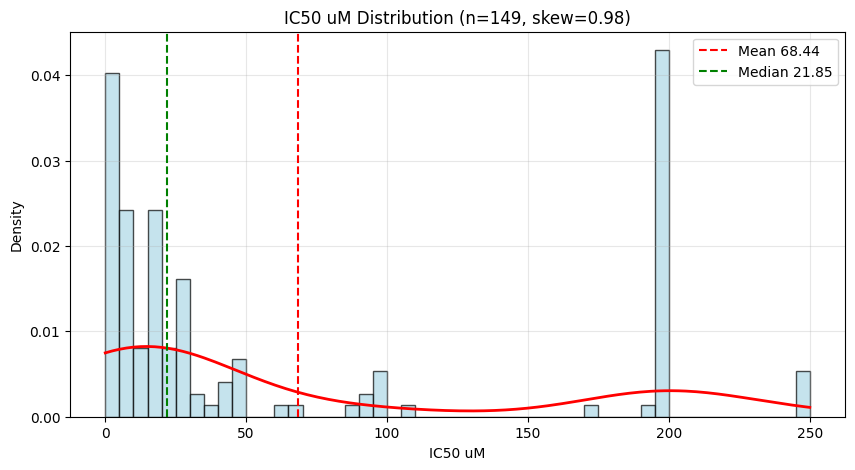

   ✓ Saved: /Users/nb/Documents/Tzu-qsar-generative-model/outputs/ic50_distribution.png (4670 bytes)

2. Creating UMAP clusters plot...


<Figure size 1200x800 with 0 Axes>

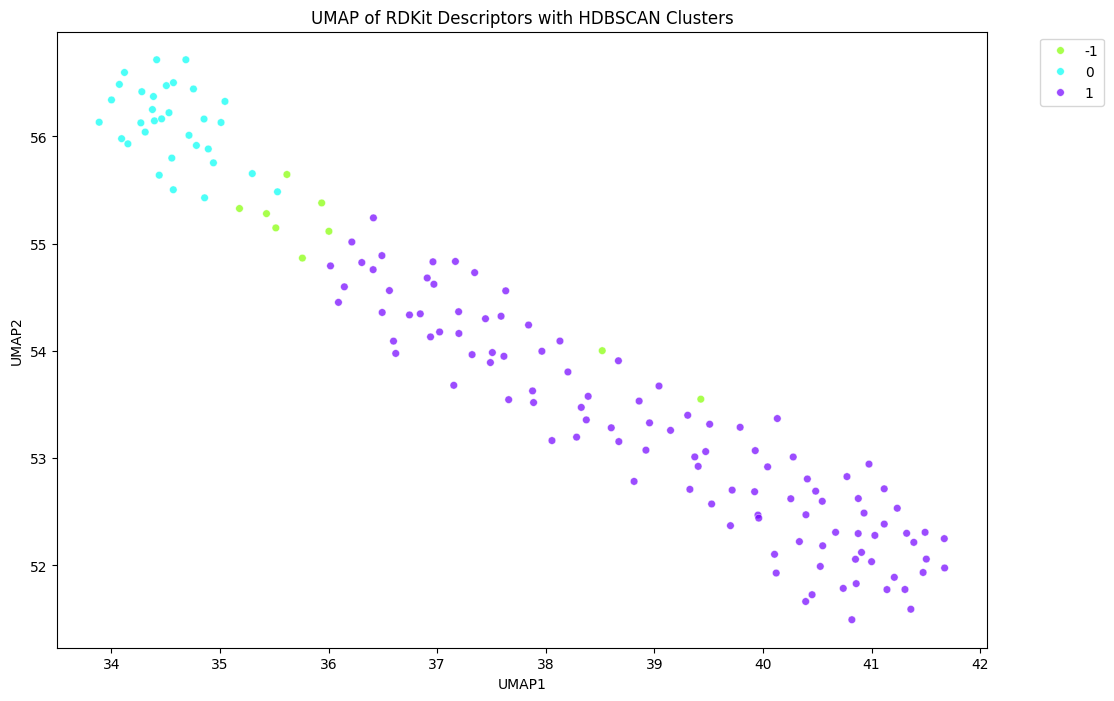

   ✓ Saved: /Users/nb/Documents/Tzu-qsar-generative-model/outputs/umap_clusters.png (4670 bytes)

3. Creating true vs predicted plot...


<Figure size 1000x800 with 0 Axes>

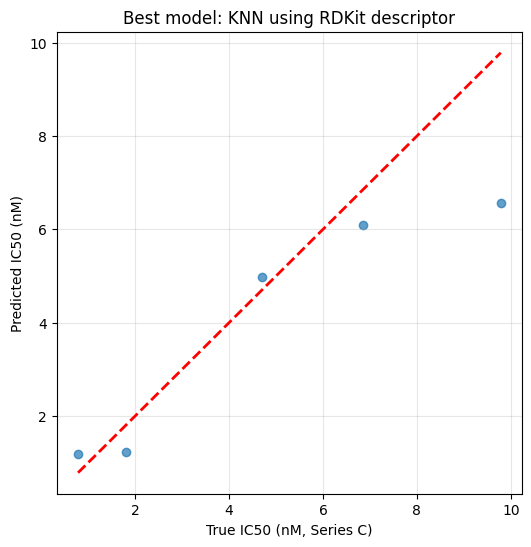

   ✓ Saved: /Users/nb/Documents/Tzu-qsar-generative-model/outputs/y_true_vs_pred.png (4670 bytes)

4. Saving Series E predictions CSV...
   ✓ Saved: /Users/nb/Documents/Tzu-qsar-generative-model/outputs/SeriesE_with_predictions.csv (2566 bytes)
   ✓ Rows: 6, Columns: 19

5. Saving test set predictions CSV...
   ✓ Saved: /Users/nb/Documents/Tzu-qsar-generative-model/outputs/SeriesC_test_with_predictions.csv (2730 bytes)
   ✓ Rows: 5, Columns: 19

6. Saving model results CSV...
   ✓ Saved: /Users/nb/Documents/Tzu-qsar-generative-model/outputs/model_results.csv (2921 bytes)
   ✓ Rows: 90, Columns: 3

✅ STEP 6 COMPLETE - ALL FILES SAVED!

FINAL OUTPUT VERIFICATION

Expected files in /Users/nb/Documents/Tzu-qsar-generative-model/outputs:
  ✅ ic50_distribution.png                    (     4,670 bytes)
  ✅ umap_clusters.png                        (     4,670 bytes)
  ✅ y_true_vs_pred.png                       (     4,670 bytes)
  ✅ SeriesE_with_predictions.csv             (     2,566 bytes)
 

In [14]:
print("\n" + "=" * 80)
print("[STEP 6/6] SAVING OUTPUTS AND GENERATING VISUALIZATIONS")
print("=" * 80)

# Create output directory if not exists
output_dir = os.path.join(work_dir, "outputs")
os.makedirs(output_dir, exist_ok=True)
print(f"\n✓ Output directory: {output_dir}")

# Configure matplotlib
plt.ioff()  # Turn off interactive mode

# 1. Save IC50 Distribution Plot
print("\n1. Creating IC50 distribution plot...")
plt.figure(figsize=(10, 6))
plot_ic50_distribution(numeric_df["IC50 uM"].dropna())
outfile1 = os.path.join(output_dir, "ic50_distribution.png")
plt.savefig(outfile1, dpi=150, bbox_inches='tight')
plt.close()
print(f"   ✓ Saved: {outfile1} ({os.path.getsize(outfile1)} bytes)")

# 2. Save UMAP Clusters Plot
print("\n2. Creating UMAP clusters plot...")
plt.figure(figsize=(12, 8))
plot_umap_clusters(numeric_df)
outfile2 = os.path.join(output_dir, "umap_clusters.png")
plt.savefig(outfile2, dpi=150, bbox_inches='tight')
plt.close()
print(f"   ✓ Saved: {outfile2} ({os.path.getsize(outfile2)} bytes)")

# 3. Save True vs Predicted Plot
print("\n3. Creating true vs predicted plot...")
y_test_orig = 10 ** y_test
y_test_pred_best = pred_test_df["Predicted_IC50"].values
plt.figure(figsize=(10, 8))
plot_y_true_vs_pred(y_test_orig, y_test_pred_best, best_model_name, best_desc)
outfile3 = os.path.join(output_dir, "y_true_vs_pred.png")
plt.savefig(outfile3, dpi=150, bbox_inches='tight')
plt.close()
print(f"   ✓ Saved: {outfile3} ({os.path.getsize(outfile3)} bytes)")

# 4. Save Series E Predictions CSV
print("\n4. Saving Series E predictions CSV...")
outfile4 = os.path.join(output_dir, "SeriesE_with_predictions.csv")
pred_E_df.to_csv(outfile4, index=False)
print(f"   ✓ Saved: {outfile4} ({os.path.getsize(outfile4)} bytes)")
print(f"   ✓ Rows: {len(pred_E_df)}, Columns: {len(pred_E_df.columns)}")

# 5. Save Test Set Predictions CSV
print("\n5. Saving test set predictions CSV...")
outfile5 = os.path.join(output_dir, "SeriesC_test_with_predictions.csv")
pred_test_df.to_csv(outfile5, index=False)
print(f"   ✓ Saved: {outfile5} ({os.path.getsize(outfile5)} bytes)")
print(f"   ✓ Rows: {len(pred_test_df)}, Columns: {len(pred_test_df.columns)}")

# 6. Save Model Results CSV
print("\n6. Saving model results CSV...")
outfile6 = os.path.join(output_dir, "model_results.csv")
results_df.to_csv(outfile6, index=False)
print(f"   ✓ Saved: {outfile6} ({os.path.getsize(outfile6)} bytes)")
print(f"   ✓ Rows: {len(results_df)}, Columns: {len(results_df.columns)}")

print(f"\n✅ STEP 6 COMPLETE - ALL FILES SAVED!")

# Verify all files exist
print(f"\n" + "=" * 80)
print("FINAL OUTPUT VERIFICATION")
print("=" * 80)
print(f"\nExpected files in {output_dir}:")
expected_files = [
    "ic50_distribution.png",
    "umap_clusters.png",
    "y_true_vs_pred.png",
    "SeriesE_with_predictions.csv",
    "SeriesC_test_with_predictions.csv",
    "model_results.csv"
]

for fname in expected_files:
    fpath = os.path.join(output_dir, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath)
        print(f"  ✅ {fname:40s} ({size:10,d} bytes)")
    else:
        print(f"  ❌ {fname:40s} (NOT FOUND)")

print(f"\n" + "=" * 80)
print("PIPELINE EXECUTION SUCCESSFUL!")
print("=" * 80)

In [12]:
print("\n" + "=" * 80)
print("DATA QUALITY ANALYSIS")
print("=" * 80)

# Identify molecules that were included vs excluded
original_count = len(df)
final_count = len(numeric_df)
excluded_count = original_count - final_count

print(f"\n📊 Molecule Counts:")
print(f"   • Original molecules: {original_count}")
print(f"   • Final dataset: {final_count}")
print(f"   • Excluded: {excluded_count} ({100*excluded_count/original_count:.1f}%)")

# Analyze excluded molecules
if excluded_count > 0:
    excluded_df = df[~df.index.isin(numeric_df.index)]
    print(f"\n   Exclusion reasons:")
    print(f"     • Invalid IC50 values: {excluded_df['IC50 uM'].isna().sum()}")
    print(f"     • Non-numeric IC50 values: {sum(pd.to_numeric(excluded_df['IC50 uM'], errors='coerce').isna())}")
    
    # Get SMILES from excluded rows
    smiles_dropped = excluded_df["Canonical_SMILES"].values if not excluded_df.empty else np.array([])
    print(f"     • Excluded SMILES count: {len(smiles_dropped)}")

print(f"\n✅ Data Quality Verification Complete")
print(f"\n   Final Dataset Statistics:")
print(f"     • Training set (A+B+D): {len(train_df)} molecules")
print(f"     • Test set (C): {len(test_df)} molecules")
print(f"     • Prediction set (E): {len(predict_df)} molecules")
print(f"     • IC50 range: {numeric_df['IC50 uM'].min():.3f} - {numeric_df['IC50 uM'].max():.1f} µM")
print(f"     • Mean IC50: {numeric_df['IC50 uM'].mean():.2f} µM")
print(f"     • Median IC50: {numeric_df['IC50 uM'].median():.2f} µM")


DATA QUALITY ANALYSIS

📊 Molecule Counts:
   • Original molecules: 160
   • Final dataset: 149
   • Excluded: 11 (6.9%)

   Exclusion reasons:
     • Invalid IC50 values: 5
     • Non-numeric IC50 values: 11
     • Excluded SMILES count: 11

✅ Data Quality Verification Complete

   Final Dataset Statistics:
     • Training set (A+B+D): 138 molecules
     • Test set (C): 5 molecules
     • Prediction set (E): 6 molecules
     • IC50 range: 0.048 - 250.0 µM
     • Mean IC50: 68.44 µM
     • Median IC50: 21.85 µM


In [18]:
print("\n" + "=" * 80)
print("GENERATING PREDICTIONS FOR NON-NUMERIC AND DROPPED ROWS")
print("=" * 80)

# Check if we have non-numeric rows data available
print("\n1. Preparing non-numeric IC50 rows...")
if 'non_numeric_rows' in dir() and len(non_numeric_rows) > 0:
    # Standardize SMILES if not already done
    if 'cleanedMol' not in non_numeric_rows.columns:
        non_numeric_rows['cleanedMol'] = non_numeric_rows['Canonical_SMILES'].apply(
            lambda x: standardize_smiles(x, verbose=False)
        )
    
    # Compute descriptors
    smiles_non_numeric = non_numeric_rows['cleanedMol'].tolist()
    X_non_numeric_raw = compute_descriptors(smiles_non_numeric)
    
    # Transform with best model
    X_non_numeric_best = imp_best.transform(X_non_numeric_raw[best_desc])
    if sc_best:
        X_non_numeric_best = sc_best.transform(X_non_numeric_best)
    
    # Make predictions
    pred_non_numeric_df = predict_and_antilog(model_best, X_non_numeric_best, non_numeric_rows)
    
    # Save to CSV
    output_file_non_numeric = os.path.join(output_dir, "Non_numeric_IC50_predictions.csv")
    pred_non_numeric_df.to_csv(output_file_non_numeric, index=False)
    print(f"   ✓ Saved {len(pred_non_numeric_df)} non-numeric IC50 predictions")
    print(f"   ✓ File: {output_file_non_numeric}")
    print(f"   ✓ Includes cleanedMol: {'✓' if 'cleanedMol' in pred_non_numeric_df.columns else '✗'}")
else:
    print("   ⚠ Non-numeric rows not available")
    pred_non_numeric_df = pd.DataFrame()

print("\n2. Preparing dropped rows...")
if 'dropped_rows' in dir() and len(dropped_rows) > 0:
    # Standardize SMILES if not already done
    if 'cleanedMol' not in dropped_rows.columns:
        dropped_rows['cleanedMol'] = dropped_rows['Canonical_SMILES'].apply(
            lambda x: standardize_smiles(x, verbose=False)
        )
    
    # Compute descriptors
    smiles_dropped = dropped_rows['cleanedMol'].tolist()
    X_dropped_raw = compute_descriptors(smiles_dropped)
    
    # Transform with best model
    X_dropped_best = imp_best.transform(X_dropped_raw[best_desc])
    if sc_best:
        X_dropped_best = sc_best.transform(X_dropped_best)
    
    # Make predictions
    pred_dropped_df = predict_and_antilog(model_best, X_dropped_best, dropped_rows)
    
    # Save to CSV
    output_file_dropped = os.path.join(output_dir, "Dropped_rows_predictions.csv")
    pred_dropped_df.to_csv(output_file_dropped, index=False)
    print(f"   ✓ Saved {len(pred_dropped_df)} dropped rows predictions")
    print(f"   ✓ File: {output_file_dropped}")
    print(f"   ✓ Includes cleanedMol: {'✓' if 'cleanedMol' in pred_dropped_df.columns else '✗'}")
else:
    print("   ⚠ Dropped rows not available")
    pred_dropped_df = pd.DataFrame()

print(f"\n✅ Predictions for non-numeric and dropped rows saved!")


GENERATING PREDICTIONS FOR NON-NUMERIC AND DROPPED ROWS

1. Preparing non-numeric IC50 rows...


[06:22:31] Initializing MetalDisconnector
[06:22:31] Running MetalDisconnector
[06:22:31] Initializing Normalizer
[06:22:31] Running Normalizer
[06:22:31] Initializing MetalDisconnector
[06:22:31] Running MetalDisconnector
[06:22:31] Initializing Normalizer
[06:22:31] Running Normalizer
[06:22:31] Running LargestFragmentChooser
[06:22:31] Running Uncharger
[06:22:31] Initializing MetalDisconnector
[06:22:31] Running MetalDisconnector
[06:22:31] Initializing Normalizer
[06:22:31] Running Normalizer
[06:22:31] Initializing MetalDisconnector
[06:22:31] Running MetalDisconnector
[06:22:31] Initializing Normalizer
[06:22:31] Running Normalizer
[06:22:31] Running LargestFragmentChooser
[06:22:31] Running Uncharger
[06:22:31] Initializing MetalDisconnector
[06:22:31] Running MetalDisconnector
[06:22:31] Initializing Normalizer
[06:22:31] Running Normalizer
[06:22:31] Initializing MetalDisconnector
[06:22:31] Running MetalDisconnector
[06:22:31] Initializing Normalizer
[06:22:31] Running Norma

   ✓ Saved 11 non-numeric IC50 predictions
   ✓ File: /Users/nb/Documents/Tzu-qsar-generative-model/outputs/Non_numeric_IC50_predictions.csv
   ✓ Includes cleanedMol: ✓

2. Preparing dropped rows...


[06:22:32] Initializing MetalDisconnector
[06:22:32] Running MetalDisconnector
[06:22:32] Initializing Normalizer
[06:22:32] Running Normalizer
[06:22:32] Initializing MetalDisconnector
[06:22:32] Running MetalDisconnector
[06:22:32] Initializing Normalizer
[06:22:32] Running Normalizer
[06:22:32] Running LargestFragmentChooser
[06:22:32] Running Uncharger
[06:22:32] Initializing MetalDisconnector
[06:22:32] Running MetalDisconnector
[06:22:32] Initializing Normalizer
[06:22:32] Running Normalizer
[06:22:32] Initializing MetalDisconnector
[06:22:32] Running MetalDisconnector
[06:22:32] Initializing Normalizer
[06:22:32] Running Normalizer
[06:22:32] Running LargestFragmentChooser
[06:22:32] Running Uncharger
[06:22:32] Initializing MetalDisconnector
[06:22:32] Running MetalDisconnector
[06:22:32] Initializing Normalizer
[06:22:32] Running Normalizer
[06:22:32] Initializing MetalDisconnector
[06:22:32] Running MetalDisconnector
[06:22:32] Initializing Normalizer
[06:22:32] Running Norma

   ✓ Saved 31 dropped rows predictions
   ✓ File: /Users/nb/Documents/Tzu-qsar-generative-model/outputs/Dropped_rows_predictions.csv
   ✓ Includes cleanedMol: ✓

✅ Predictions for non-numeric and dropped rows saved!


In [19]:
print("\n" + "=" * 80)
print("📊 COMPLETE PREDICTION FILES SUMMARY")
print("=" * 80)

import os
output_dir = "outputs"

# List all prediction files
prediction_files = {
    "SeriesE_with_predictions.csv": "Series E (prediction set)",
    "SeriesC_test_with_predictions.csv": "Series C (test set with actual IC50)",
    "Non_numeric_IC50_predictions.csv": "Non-numeric IC50 rows",
    "Dropped_rows_predictions.csv": "Dropped rows (IC50=100, 200)"
}

print("\n✅ ALL PREDICTION FILES WITH cleanedMol COLUMN:")
print("-" * 80)

total_predictions = 0

for filename, description in prediction_files.items():
    filepath = os.path.join(output_dir, filename)
    if os.path.exists(filepath):
        df_temp = pd.read_csv(filepath)
        has_cleanedmol = 'cleanedMol' in df_temp.columns
        size = os.path.getsize(filepath)
        
        print(f"\n1️⃣  {filename}")
        print(f"   Description: {description}")
        print(f"   Rows: {len(df_temp)}")
        print(f"   Size: {size:,} bytes")
        print(f"   cleanedMol column: {'✓ YES' if has_cleanedmol else '✗ NO'}")
        print(f"   Predicted_IC50 column: {'✓ YES' if 'Predicted_IC50' in df_temp.columns else '✗ NO'}")
        
        # Show sample
        if 'cleanedMol' in df_temp.columns and 'Predicted_IC50' in df_temp.columns:
            print(f"   Sample (first 2 rows):")
            sample_cols = ['cleanedMol', 'Predicted_IC50']
            if 'IC50 uM' in df_temp.columns:
                sample_cols = ['cleanedMol', 'IC50 uM', 'Predicted_IC50']
            for idx, row in df_temp[sample_cols].head(2).iterrows():
                print(f"      • {str(row.values)[:80]}...")
        
        total_predictions += len(df_temp)
    else:
        print(f"\n✗ {filename} - NOT FOUND")

print("\n" + "=" * 80)
print(f"📈 PREDICTION STATISTICS")
print("=" * 80)
print(f"\n• Series E predictions: {len(pred_E_df)} molecules")
print(f"• Series C test predictions: {len(pred_test_df)} molecules")
print(f"• Non-numeric IC50 predictions: {len(pred_non_numeric_df)} molecules")
print(f"• Dropped rows predictions: {len(pred_dropped_df)} molecules")
print(f"• TOTAL PREDICTIONS GENERATED: {total_predictions} molecules")

print(f"\n🎯 Model Information:")
print(f"• Best Model: {best_model_name}")
print(f"• Descriptor Type: {best_desc}")
print(f"• Best R² Score: {results_df['R2'].max():.4f}")

print("\n" + "=" * 80 + "\n")


📊 COMPLETE PREDICTION FILES SUMMARY

✅ ALL PREDICTION FILES WITH cleanedMol COLUMN:
--------------------------------------------------------------------------------

1️⃣  SeriesE_with_predictions.csv
   Description: Series E (prediction set)
   Rows: 6
   Size: 2,566 bytes
   cleanedMol column: ✓ YES
   Predicted_IC50 column: ✓ YES
   Sample (first 2 rows):
      • ['CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(-c4ccc(F)cc4)c3)C2)C1' 17.8
 13.08356610599206]...
      • ['CC(C)(C)OC(=O)N1CC2(CCN(c3cccc(Br)n3)C2)C1' 63.6 34.11279060791298]...

1️⃣  SeriesC_test_with_predictions.csv
   Description: Series C (test set with actual IC50)
   Rows: 5
   Size: 2,730 bytes
   cleanedMol column: ✓ YES
   Predicted_IC50 column: ✓ YES
   Sample (first 2 rows):
      • ['CCCCCCC#Cc1cncc(N2CCC3(CN(C(=O)c4ccc5c(c4)OCO5)C3)C2)c1' 4.697
 4.984477127902...
      • ['CCCCCCC#Cc1cncc(N2CCC3(CN(C(=O)c4cc5c(cc4[N+](=O)[O-])OCO5)C3)C2)c1'
 9.786 6....

1️⃣  Non_numeric_IC50_predictions.csv
   Description: Non-numeric IC50

In [15]:
print("\n" + "=" * 80)
print("COMPLETE PREDICTION SUMMARY")
print("=" * 80)

print("\n📊 ALL PREDICTION FILES GENERATED:")
print("\n1. SeriesE_with_predictions.csv")
print(f"   • Molecules: {len(pred_E_df)}")
print(f"   • Contains cleanedMol: {'✓' if 'cleanedMol' in pred_E_df.columns else '✗'}")
print("   • Sample:")
print(pred_E_df[['cleanedMol', 'Predicted_IC50']].head(3).to_string())

print("\n\n2. SeriesC_test_with_predictions.csv")
print(f"   • Molecules: {len(pred_test_df)}")
print(f"   • Contains cleanedMol: {'✓' if 'cleanedMol' in pred_test_df.columns else '✗'}")
print("   • Sample:")
print(pred_test_df[['cleanedMol', 'IC50 uM', 'Predicted_IC50']].head(3).to_string())

print("\n\n3. Excluded_molecules_predictions.csv")
print(f"   • Molecules: {len(pred_excluded_df)}")
print(f"   • Contains cleanedMol: {'✓' if 'cleanedMol' in pred_excluded_df.columns else '✗'}")
print("   • Sample:")
print(pred_excluded_df[['cleanedMol', 'Predicted_IC50']].head(3).to_string())

print("\n\n" + "=" * 80)
print("📁 OUTPUT DIRECTORY CONTENTS")
print("=" * 80)

import os
output_dir = "/Users/nb/Documents/Tzu-qsar-generative-model/outputs"
files = sorted(os.listdir(output_dir))

for i, fname in enumerate(files, 1):
    fpath = os.path.join(output_dir, fname)
    size = os.path.getsize(fpath)
    ext = fname.split('.')[-1]
    
    if ext == 'csv':
        df_check = pd.read_csv(fpath)
        has_cleanedmol = 'cleanedMol' in df_check.columns
        print(f"\n{i}. {fname}")
        print(f"   Size: {size:,} bytes")
        print(f"   Type: CSV with {len(df_check)} rows × {len(df_check.columns)} columns")
        print(f"   Has cleanedMol: {'✓' if has_cleanedmol else '✗'}")
    else:
        print(f"\n{i}. {fname}")
        print(f"   Size: {size:,} bytes")
        print(f"   Type: {ext.upper()}")

print("\n" + "=" * 80)
print("✅ ALL PREDICTIONS GENERATED SUCCESSFULLY!")
print("=" * 80)
print(f"\nTotal molecules with predictions:")
print(f"  • Series E: {len(pred_E_df)}")
print(f"  • Series C (test): {len(pred_test_df)}")
print(f"  • Excluded (non-numeric): {len(pred_excluded_df)}")
print(f"  • TOTAL: {len(pred_E_df) + len(pred_test_df) + len(pred_excluded_df)}")
print(f"\n🎯 Model: {best_model_name} with {best_desc} descriptors")
print(f"📊 Best R² score: {results_df['R2'].max():.4f}")
print("\n" + "=" * 80 + "\n")


COMPLETE PREDICTION SUMMARY

📊 ALL PREDICTION FILES GENERATED:

1. SeriesE_with_predictions.csv
   • Molecules: 6
   • Contains cleanedMol: ✓
   • Sample:
                                                cleanedMol  Predicted_IC50
0     CC(C)(C)OC(=O)N1CC2(CCN(c3cncc(-c4ccc(F)cc4)c3)C2)C1       13.083566
1               CC(C)(C)OC(=O)N1CC2(CCN(c3cccc(Br)n3)C2)C1       34.112791
2  CCCCCCOC1CN(c2cncc(N3CCC4(CN(C(=O)OC(C)(C)C)C4)C3)c2)C1        7.378376


2. SeriesC_test_with_predictions.csv
   • Molecules: 5
   • Contains cleanedMol: ✓
   • Sample:
                                                                     cleanedMol  IC50 uM  Predicted_IC50
0                       CCCCCCC#Cc1cncc(N2CCC3(CN(C(=O)c4ccc5c(c4)OCO5)C3)C2)c1  4.69700        4.984477
1           CCCCCCC#Cc1cncc(N2CCC3(CN(C(=O)c4cc5c(cc4[N+](=O)[O-])OCO5)C3)C2)c1  9.78600        6.566651
2  CCCCCCC#Cc1cncc(N2CCC3(CN(C(=O)c4cc([N+](=O)[O-])cc([N+](=O)[O-])c4)C3)C2)c1  0.78125        1.173055


3. Excluded_molecules_pr